In [1]:
import numpy as np
import matplotlib.pyplot as plt

from plots import *
from src import *

# Enable SVG in Jupyter notebooks.
%config InlineBackend.figure_formats = ['svg']

# Microwave-optical transduction fidelity

## Parameters

In [2]:
params = {
    'kappa_a' : 13.2,   # Optical linewidth [2π * GHz].
    'kappa_b' : 0.002,  # Microwave linewidth [2π * GHz].
    'omega_b' : 5.0,    # Microwave frequency [2π * GHz].
    'Delta' : 5.0,      # Optical detuning [2π * GHz].
    'eta_a' : 1.0,      # Optical collection efficiency.
    'eta_b' : 1.0,      # Microwave collection efficiency.
}

Delta_a = 0.2                                               # Optical detuning [2π * GHz].
z = 1 / abs(1 - (params['omega_b']/Delta_a)**2)             # Parametric coupling ratio from Eq. (24).

g_t = np.sqrt(params['kappa_a'] * params['kappa_b']) / 2    # Transduction rate.
g_s = z * g_t                                               # Two-mode squeezing rate.

In [3]:
# Initialise the transducer.
transducer = Transducer(**params)

# Noise moments at the central frequency.
S, L = transducer.channel(params['omega_b'], g_t, g_s)
moments = aout_moments(S, L)

## Numerics

In [4]:
# Mean photon numbers.
n_fock = np.arange(1, 16)             # Number states (integer)
nbar_coh = np.linspace(1.0, 15, 61)   # Coherent states (continuous)
nbar_gkp = np.linspace(1.0, 15, 61)   # GKP states (continuous)

In [5]:
# Fock state fidelity.
F_fock = np.empty(len(n_fock))
for j, n in enumerate(n_fock):
    F_fock[j] = fidelity(lambda w: Phi_fock(w, n), *moments)

# Coherent state fidelity.
F_coh  = np.empty(len(nbar_coh))
for j, nbar in enumerate(nbar_coh):
    F_coh[j] = fidelity(lambda w: Phi_coherent(w, np.sqrt(nbar)), *moments)

In [6]:
# GKP average gate fidelity (App. F.2), same channel asymmetry z as above.
F_gkp = 1 - np.array([gkp_infidelity(n, *gkp_channel_params(kappa_a=params['kappa_a'], kappa_b=params['kappa_b'], omega_b=params['omega_b'], z=z, eta_a=params['eta_a'], eta_b=params['eta_b'])) for n in nbar_gkp])

## Figure

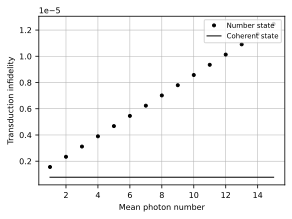

In [7]:
fig, axs = plt.subplots(
    nrows = 1,
    ncols = 1,
    figsize = (
        1.2 * FIG_SIZES['onecol'],
        0.9 * FIG_SIZES['onecol']
        ),
    sharey = True,
    )

label = fr'$\Delta_a/\omega_b = {Delta_a/params['omega_b']:g}$'
axs.plot(n_fock, 1-F_fock, c='k', marker='o', ls='', label='Number state')
axs.plot(nbar_coh, 1-F_coh, c='k', label='Coherent state')
# axs.plot(nbar_gkp, 1-F_gkp, c='k', ls='--', label='GKP state')

# axs.semilogy()
axs.grid('both')
# axs.set_ylim(6e-7, 2e-5)
# axs.set_xlim(0, 15)

axs.set_xlabel('Mean photon number')
axs.set_ylabel('Transduction infidelity')
axs.legend(loc='upper right')

fig.tight_layout()
fig.savefig('fig/transduction.pdf', bbox_inches='tight')